In [70]:
# 1 - Imports & settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# create a folder to store charts
os.makedirs("charts", exist_ok=True)


In [72]:
# 2 - Load dataset from GitHub
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Loaded shape:", df.shape)
display(df.head())

Loaded shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [73]:
# 3 - Inspect
print("Columns:", df.columns.tolist())
print("\nInfo:")
display(df.info())
print("\nMissing values per column:")
display(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None


Missing values per column:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Duplicate rows: 0


In [74]:
# 4 - Cleaning
df_clean = df.copy()

# Drop duplicates if any
if df_clean.duplicated().sum() > 0:
    df_clean.drop_duplicates(inplace=True)

# Fill Age with median
if 'Age' in df_clean.columns:
    df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Fill Embarked with mode
if 'Embarked' in df_clean.columns:
    df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# Fill Fare with median if any missing
if 'Fare' in df_clean.columns:
    df_clean['Fare'].fillna(df_clean['Fare'].median(), inplace=True)

# Convert types
if 'Pclass' in df_clean.columns:
    df_clean['Pclass'] = df_clean['Pclass'].astype('category')
if 'Survived' in df_clean.columns:
    df_clean['Survived'] = df_clean['Survived'].astype(int)

# Save cleaned CSV
df_clean.to_csv("titanic_cleaned.csv", index=False)
print("Cleaned dataset saved as titanic_cleaned.csv")


Cleaned dataset saved as titanic_cleaned.csv


/tmp/ipython-input-4115344776.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/tmp/ipython-input-4115344776.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [75]:
# 5 - helper: save and show
def save_and_show(fig, filename, show=True):
    path = os.path.join("charts", filename)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    if show:
        display(fig)
    plt.close(fig)
    print("Saved:", path)


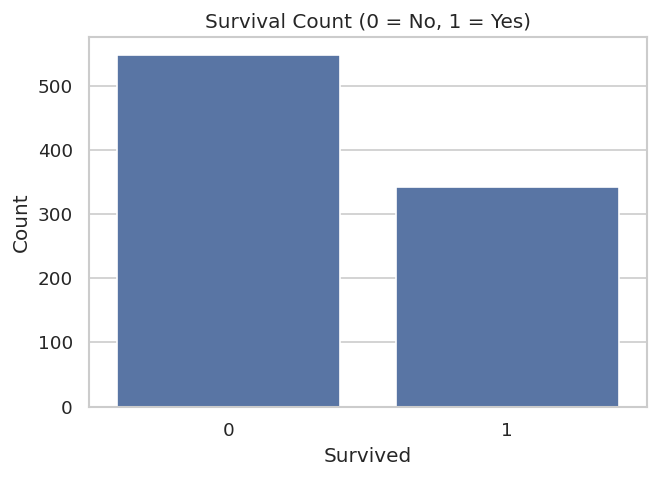

Saved: charts/survival_count.png


In [76]:
# 6 - Survival count
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x='Survived', data=df_clean, ax=ax)
ax.set_title("Survival Count (0 = No, 1 = Yes)")
ax.set_xlabel("Survived")
ax.set_ylabel("Count")
save_and_show(fig, "survival_count.png")


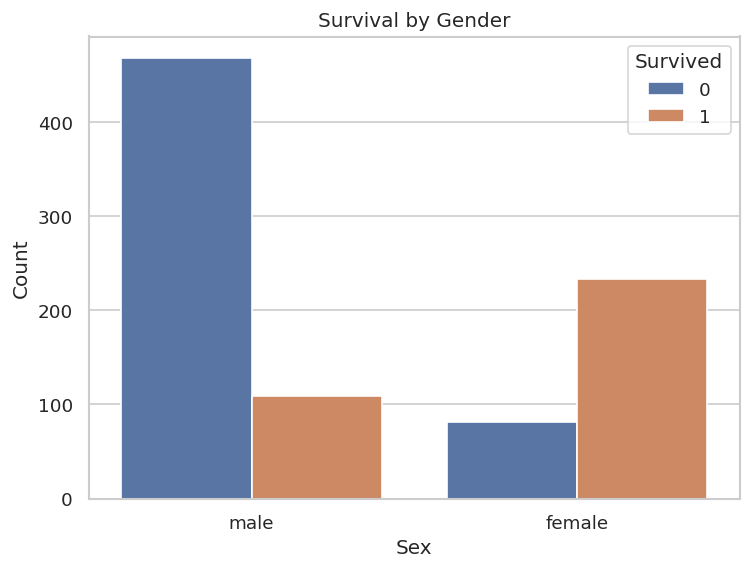

Saved: charts/survival_by_gender.png


In [77]:
# 7 - Survival by Gender
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(x='Sex', hue='Survived', data=df_clean, ax=ax)
ax.set_title("Survival by Gender")
ax.set_xlabel("Sex")
ax.set_ylabel("Count")
save_and_show(fig, "survival_by_gender.png")


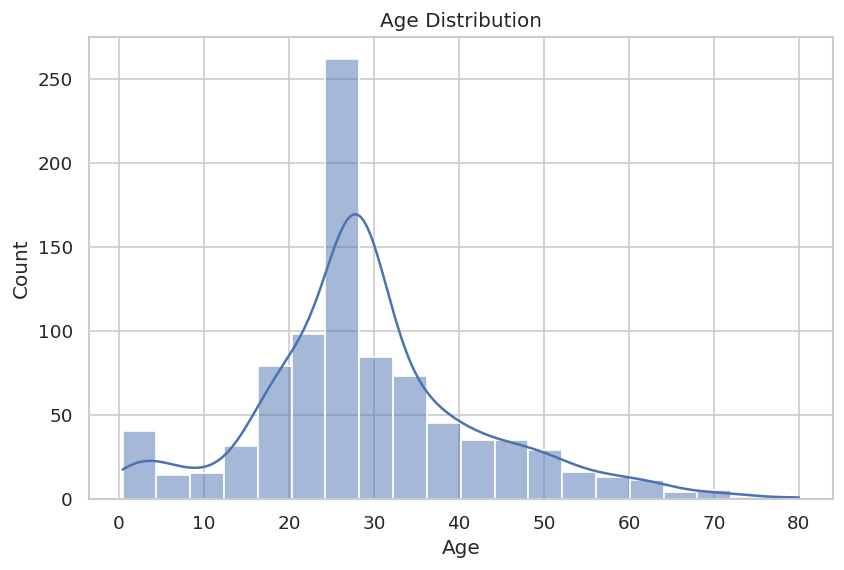

Saved: charts/age_distribution.png


In [78]:
# 8 - Age distribution
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df_clean['Age'].dropna(), bins=20, kde=True, ax=ax)
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
save_and_show(fig, "age_distribution.png")


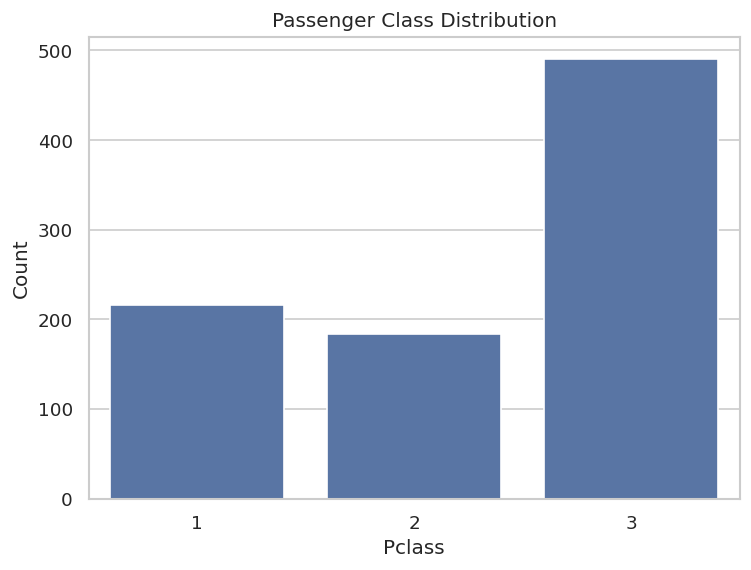

Saved: charts/pclass_distribution.png


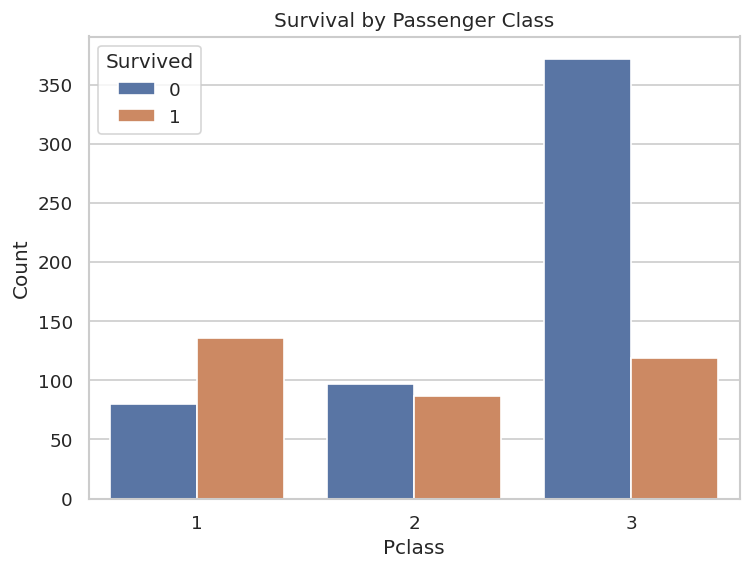

Saved: charts/survival_by_pclass.png


In [79]:
# 9 - Pclass distribution
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(x='Pclass', data=df_clean, ax=ax)
ax.set_title("Passenger Class Distribution")
ax.set_xlabel("Pclass")
ax.set_ylabel("Count")
save_and_show(fig, "pclass_distribution.png")

# survival by Pclass
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(x='Pclass', hue='Survived', data=df_clean, ax=ax)
ax.set_title("Survival by Passenger Class")
ax.set_xlabel("Pclass")
ax.set_ylabel("Count")
save_and_show(fig, "survival_by_pclass.png")


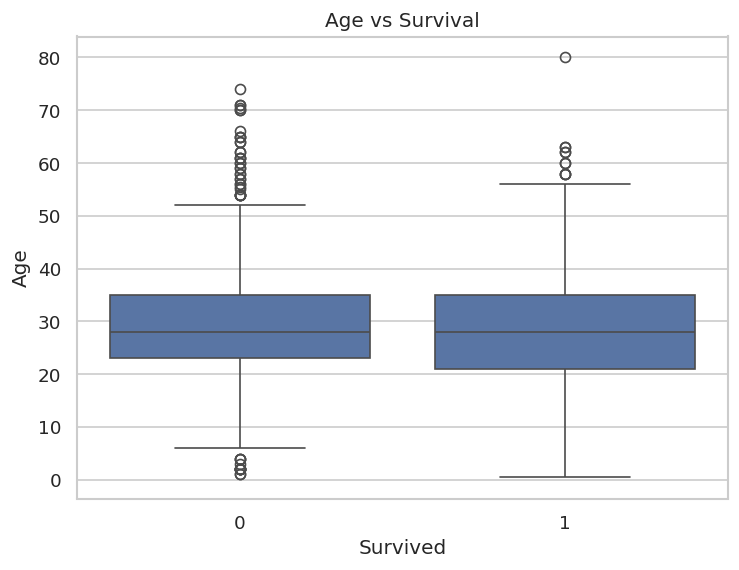

Saved: charts/age_vs_survival_boxplot.png


In [80]:
# 10 - Boxplot Age by Survival
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(x='Survived', y='Age', data=df_clean, ax=ax)
ax.set_title("Age vs Survival")
ax.set_xlabel("Survived")
ax.set_ylabel("Age")
save_and_show(fig, "age_vs_survival_boxplot.png")


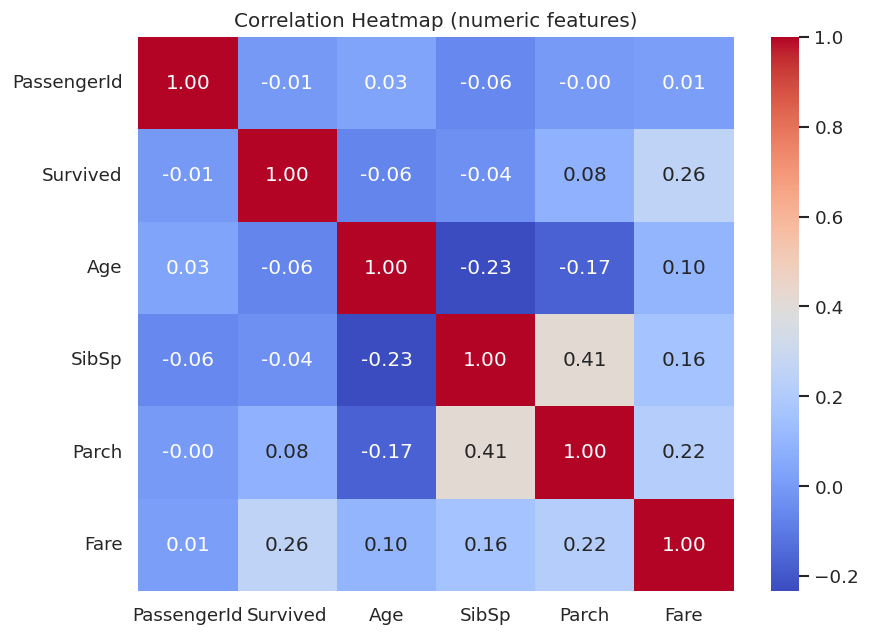

Saved: charts/correlation_heatmap.png


In [81]:
# 11 - Correlation heatmap (numeric columns)
fig, ax = plt.subplots(figsize=(8,6))
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap (numeric features)")
save_and_show(fig, "correlation_heatmap.png")


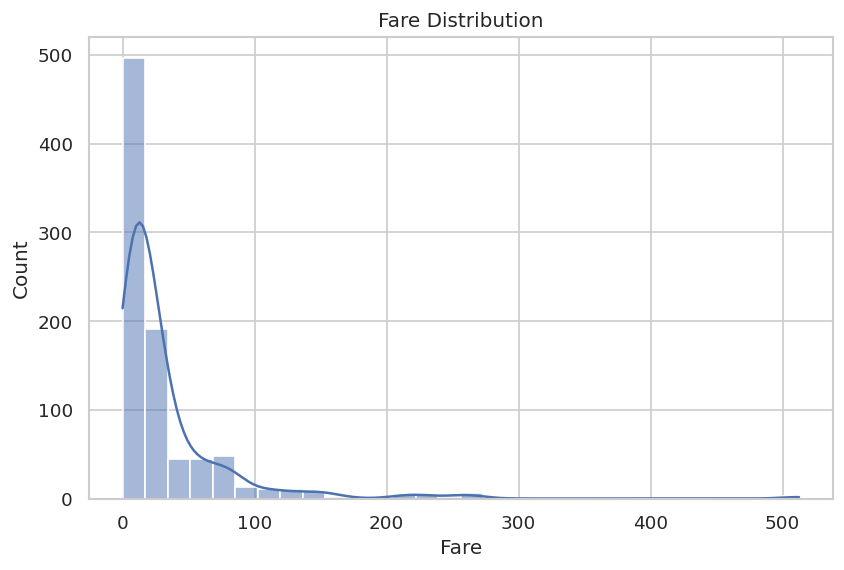

Saved: charts/fare_distribution.png


In [82]:
# 12 - Fare distribution
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df_clean['Fare'].dropna(), bins=30, kde=True, ax=ax)
ax.set_title("Fare Distribution")
ax.set_xlabel("Fare")
ax.set_ylabel("Count")
save_and_show(fig, "fare_distribution.png")


In [83]:
# 13 - List saved chart files
files = os.listdir("charts")
print("Files saved in charts/:")
for f in files:
    print(" -", f)


Files saved in charts/:
 - survival_by_gender.png
 - survival_count.png
 - pclass_distribution.png
 - age_vs_survival_boxplot.png
 - correlation_heatmap.png
 - fare_distribution.png
 - survival_by_pclass.png
 - age_distribution.png


In [84]:
# 14 - Zip charts folder
import shutil
zip_name = "charts.zip"
if os.path.exists(zip_name):
    os.remove(zip_name)
shutil.make_archive("charts", 'zip', "charts")
print("Created", zip_name, " — ready to download")


Created charts.zip  — ready to download


In [85]:
# 15 - Download charts.zip (Colab only)
from google.colab import files
files.download("charts.zip")   # this will prompt browser download


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>